In [1]:
import numpy as np

def loss(w):
    w1, w2 = w
    return 0.5 * (0.1 * w1**2 + 10 * w2**2)

def gradient(w):
    w1, w2 = w
    return np.array([0.1 * w1,10 * w2])

In [2]:
w = np.array([8.0, 2.0])
print(loss(w))
print(gradient(w))

23.2
[ 0.8 20. ]


In [3]:
def batch_gd(start, alpha=0.18, iterations=40):
    w = start.copy()
    path = [w.copy()]

    for i in range(iterations):
        g = gradient(w)
        w = w - alpha * g
        path.append(w.copy())

    return np.array(path)

In [4]:
batch_path = batch_gd(np.array([8.0, 2.0]),alpha=0.18,iterations=40)

print(batch_path[:6])

[[ 8.          2.        ]
 [ 7.856      -1.6       ]
 [ 7.714592    1.28      ]
 [ 7.57572934 -1.024     ]
 [ 7.43936622  0.8192    ]
 [ 7.30545762 -0.65536   ]]


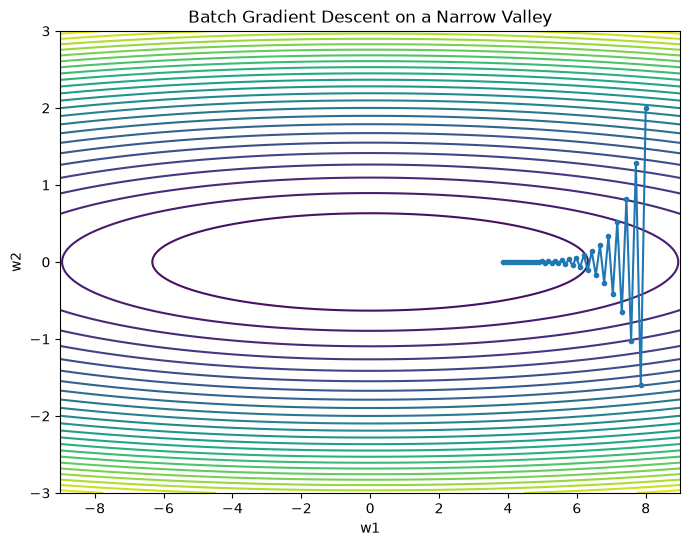

In [5]:
import matplotlib.pyplot as plt

w1_vals = np.linspace(-9, 9, 300)
w2_vals = np.linspace(-3, 3, 300)

W1, W2 = np.meshgrid(w1_vals, w2_vals)

Z = 0.5 * (0.1 * W1**2 + 10 * W2**2)

plt.figure(figsize=(8, 6))

plt.contour(W1, W2, Z, levels=25)

plt.plot(batch_path[:, 0],batch_path[:, 1],marker="o",markersize=3)

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Batch Gradient Descent on a Narrow Valley")

plt.show()

In [7]:
rng = np.random.default_rng(42)

def stochastic_gradient(w):
    noise = rng.normal(loc=0.0,scale=np.array([0.4, 3.0]))
    return gradient(w) + noise

In [8]:
def sgd(start, alpha=0.08, iterations=120):
    w = start.copy()
    path = [w.copy()]

    for i in range(iterations):
        g = stochastic_gradient(w)
        w = w - alpha * g
        path.append(w.copy())

    return np.array(path)

In [9]:
sgd_path = sgd(np.array([8.0, 2.0]),alpha=0.08,iterations=120)

print(sgd_path[:6])
print("Final:", sgd_path[-1])

[[ 8.          2.        ]
 [ 7.92624905  0.64959619]
 [ 7.83882462 -0.09581629]
 [ 7.83854715  0.29335982]
 [ 7.77174788  0.13457019]
 [ 7.71011154  0.23164458]]
Final: [3.25878775 0.13905801]


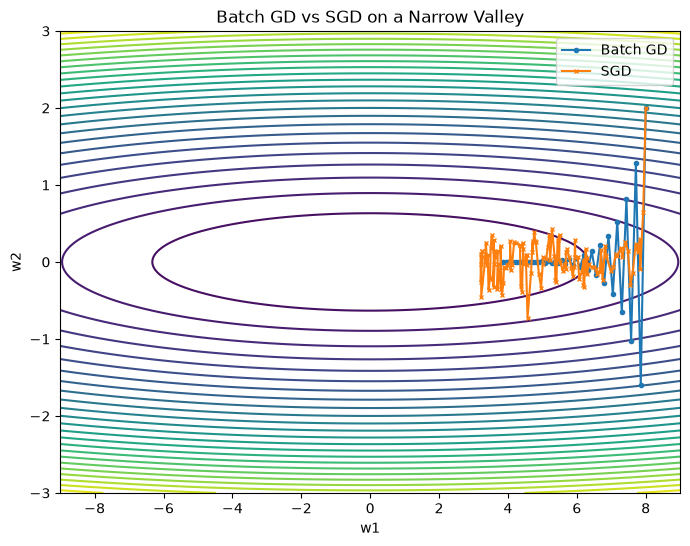

In [10]:
plt.figure(figsize=(8, 6))

plt.contour(W1, W2, Z, levels=25)

plt.plot(batch_path[:, 0],batch_path[:, 1],marker="o",markersize=3,label="Batch GD")
plt.plot(sgd_path[:, 0],sgd_path[:, 1],marker="x",markersize=3,label="SGD")

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Batch GD vs SGD on a Narrow Valley")
plt.legend()

plt.show()

In [11]:
rng_mb = np.random.default_rng(42)

def mini_batch_gradient(w, batch_size=16):
    noise_scale = np.array([0.4, 3.0]) / np.sqrt(batch_size)
    noise = rng_mb.normal(loc=0.0,scale=noise_scale)
    return gradient(w) + noise

In [12]:
def mini_batch_gd(start, alpha=0.08, iterations=120, batch_size=16):
    w = start.copy()
    path = [w.copy()]

    for i in range(iterations):
        g = mini_batch_gradient(w, batch_size)
        w = w - alpha * g
        path.append(w.copy())

    return np.array(path)

In [13]:
mini_path = mini_batch_gd(np.array([8.0, 2.0]),alpha=0.08,iterations=120,batch_size=16)

print(mini_path[:6])
print("Final:", mini_path[-1])

[[8.         2.        ]
 [7.93356226 0.46239905]
 [7.86409016 0.03604593]
 [7.81678572 0.08533996]
 [7.75322871 0.03604255]
 [7.69133729 0.05839114]]
Final: [3.10320216 0.0347645 ]


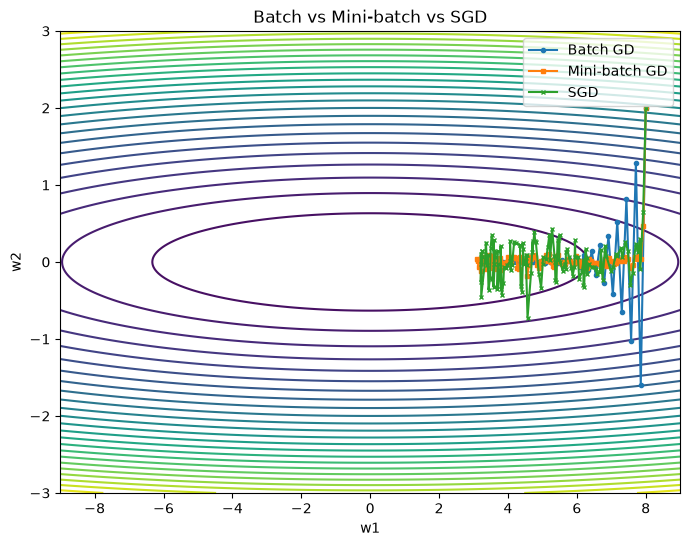

In [14]:
plt.figure(figsize=(8, 6))

plt.contour(W1, W2, Z, levels=25)

plt.plot(batch_path[:, 0],batch_path[:, 1],marker="o",markersize=3,label="Batch GD")
plt.plot(mini_path[:, 0],mini_path[:, 1],marker="s",markersize=3,label="Mini-batch GD")
plt.plot(sgd_path[:, 0],sgd_path[:, 1],marker="x",markersize=3,label="SGD")

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Batch vs Mini-batch vs SGD")
plt.legend()

plt.show()

In [18]:
def momentum_gd(start, alpha=0.18, beta=0.9, iterations=40):
    w = start.copy()
    v = np.zeros_like(w)
    path = [w.copy()]

    for i in range(iterations):
        g = gradient(w)
        v = beta * v + g
        w = w - alpha * v
        path.append(w.copy())

    return np.array(path)

In [19]:
momentum_path = momentum_gd(np.array([8.0, 2.0]),alpha=0.18,beta=0.9,iterations=40)

print(momentum_path[:6])
print("Final:", momentum_path[-1])

[[ 8.          2.        ]
 [ 7.856      -1.6       ]
 [ 7.584992   -1.96      ]
 [ 7.20455494  1.244     ]
 [ 6.7324796   1.8884    ]
 [ 6.18642717 -0.93076   ]]
Final: [0.0553526  0.06263074]


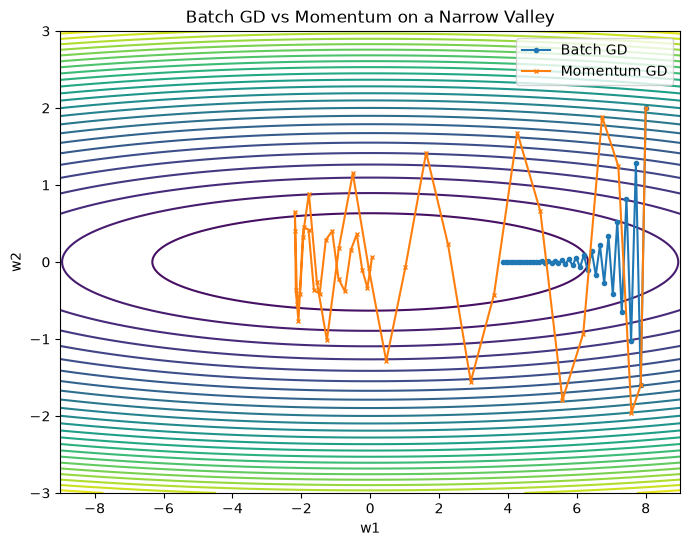

In [20]:
plt.figure(figsize=(8, 6))

plt.contour(W1, W2, Z, levels=25)

plt.plot(batch_path[:, 0],batch_path[:, 1],marker="o",markersize=3,label="Batch GD")
plt.plot(momentum_path[:, 0],momentum_path[:, 1],marker="x",markersize=3,label="Momentum GD")

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Batch GD vs Momentum on a Narrow Valley")
plt.legend()

plt.show()

In [21]:
def adam_gd(start,alpha=0.2,beta1=0.9,beta2=0.999,epsilon=1e-8,iterations=40):
    w = start.copy()
    m = np.zeros_like(w)
    v = np.zeros_like(w)
    path = [w.copy()]

    for t in range(1, iterations + 1):
        g = gradient(w)
        m = beta1 * m + (1 - beta1) * g #first moment estimate
        v = beta2 * v + (1 - beta2) * (g ** 2) #second moment estimate

        # bias correction
        m_hat = m / (1 - beta1 ** t)
        v_hat = v / (1 - beta2 ** t)

        # update
        w = w - alpha * m_hat / (np.sqrt(v_hat) + epsilon)

        path.append(w.copy())

    return np.array(path)

In [22]:
adam_path = adam_gd(np.array([8.0, 2.0]),alpha=0.2,iterations=40)

print(adam_path[:6])
print("Final:", adam_path[-1])

[[8.         2.        ]
 [7.8        1.8       ]
 [7.60014799 1.60082446]
 [7.4005477  1.40317254]
 [7.20130645 1.20787812]
 [7.00253507 1.01592731]]
Final: [1.30106166 0.20156922]


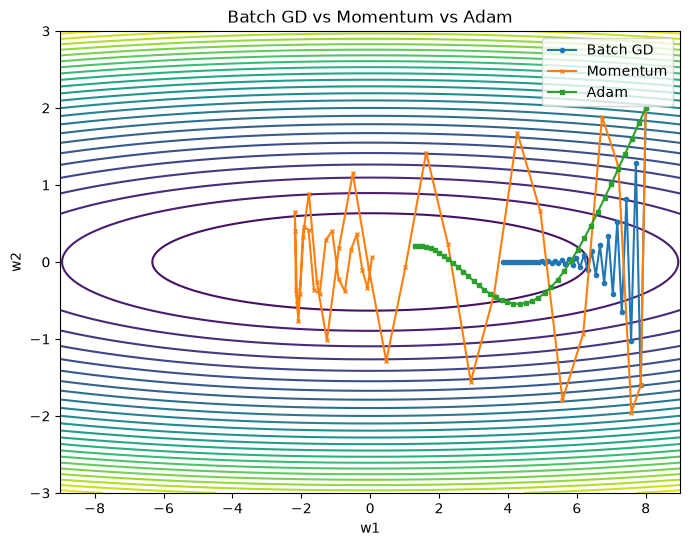

In [23]:
plt.figure(figsize=(8, 6))

plt.contour(W1, W2, Z, levels=25)

plt.plot(batch_path[:, 0],batch_path[:, 1],marker="o",markersize=3,label="Batch GD")
plt.plot(momentum_path[:, 0],momentum_path[:, 1],marker="x",markersize=3,label="Momentum")
plt.plot(adam_path[:, 0],adam_path[:, 1],marker="s",markersize=3,label="Adam")

plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Batch GD vs Momentum vs Adam")
plt.legend()

plt.show()

Batch gradient descent was reasonable because our training dataset is relatively small, with only 14,438 samples and 5 features, so computing the full gradient at each step is inexpensive. Mini-batch gradient descent would become a better choice if the dataset or model grew large enough that computing the full gradient for every update became costly.